# London is building more data centres. How many direct jobs does a typical facility create? Technical Annex
[Repository](https://github.com/a-saveleva/casa0007_project).

## Overview

This document presents a step-by-step regression modelling addressing the following main question:

**How many people are employed in data centres, and how does this relationship change with DC size or other characteristics?** Additionally, what are the basic characteristics of the data centres in London, particularly those relevant to planning (e.g. size, employment, and energy use)?

We have used the Planning London Datahub API to acquire a sample of DC using the keywords. More details [here](https://github.com/a-saveleva/casa0007_project/tree/main/data_load). All datapoints were manually validated, including their associated information, through reading their planning application materials. The main reason for using this source is the fact that the DC data is private and inaccessible for the non-commercial use due to prohibitive costs. This notebook outlines the EDA and the regression modelling.

The sample is restricted to DC in London, excluding locations such as Slough. The London dataset contains N=67 observations, but regression samples are further reduced by complete-case availability. **The main GIA–staff model uses N=36**, while additional specifications use N=35 and N=15 depending on the variables included.

In [1]:
#| include: false
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import math
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.tools import maybe_unwrap_results
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from typing import Type
from libpysal.weights import KNN
from esda.moran import Moran

pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)
notes_colour = "black"
labels_colour = "grey"

## Loading and EDA

In [2]:
# Loading the previously validated dataset. See more in data_load folder of the repository
# ____________________________________________________________________________________________________________
data_ldn = pd.read_csv(
    "data_load/final_output.csv", na_values=["NULL", "null", "None", "", "[]", "NaN"])
data_ldn["geometry"] = gpd.GeoSeries.from_wkt(data_ldn["geometry_point"])
data_ldn = gpd.GeoDataFrame(data_ldn, geometry="geometry", crs="EPSG:4326")
# ____________________________________________________________________________________________________________
# For plotting
gla_boundary = gpd.read_file("data_load/gla/London_GLA_Boundary.shp").to_crs(4326)
# ____________________________________________________________________________________________________________
# Filtering out rows that are not of interest at the moment

# data_ldn_exstg = data_ldn[data_ldn["completed"] == "Completed"].drop(axis=1, columns=['completed']) #taking only the data centres that were built #!!!!!!!!!!!!!!!!!!!!!!!
data_ldn_exstg = data_ldn
data_ldn_exstg = data_ldn_exstg[data_ldn_exstg["lpa_name"] != "Slough"]
data_ldn_exstg = data_ldn_exstg.sort_values(by="data_centre_since", ascending=True)
data_ldn_exstg.head(1)
# ____________________________________________________________________________________________________________
# Creating a set of new columns for testing and reporting
data_ldn_exstg["b8_gia_sqm_per_ha"] = data_ldn_exstg["b8_gia_sqm"] / data_ldn_exstg["application_details_site_area"] 
data_ldn_exstg["b8_gia_ha_per_site_ha"] = (data_ldn_exstg["b8_gia_sqm"] /10000) / data_ldn_exstg["application_details_site_area"]
data_ldn_exstg["b8_gia_1000_sqm"] = data_ldn_exstg["b8_gia_sqm"] / 1000
data_ldn_exstg["b8_total_staff_per_1000_sqm"] = data_ldn_exstg["b8_total_staff_fte"] / data_ldn_exstg["b8_gia_1000_sqm"]

In [3]:
len(data_ldn_exstg)

67

The dataset contains key characteristics of each data centre, covering its planning and ownership status, spatial characteristics, technical capacity, and employment profile. A subset of these variables is used in the analysis, including gross internal area (GIA), site area, electricity and IT load capacity, power density, total staff numbers, and the spatial location of each data centre.

In [4]:
#| echo: false
cols_describe = [
    "b8_total_staff_fte", "b8_gia_sqm", "application_details_site_area",
    # "b8_total_staff_per_1000_sqm", 
    # "b8_gia_sqm_per_ha", "b8_gia_ha_per_site_ha",
    "utility_total_electr_capacity_mva", "it_load_capacity_mw", "density_kw_max_per_sqm"
]
summary_table = (
    data_ldn_exstg[cols_describe]
    .describe()
    .rename(columns={
        "b8_total_staff_fte": "Staff FTE",
        "b8_gia_sqm": "GIA",
        "application_details_site_area": "Site area",
        # "b8_total_staff_per_1000_sqm": "Staff per 1000sqm",
        "b8_gia_sqm_per_ha": "GIA sqm / ha",
        "b8_gia_ha_per_site_ha": "GIA ha / site ha",
        "utility_total_electr_capacity_mva": "Elec. capacity (MVA)",
        "it_load_capacity_mw": "IT load (MW)",
        "density_kw_max_per_sqm": "Max density (kW/sqm)",
    })
    .round(2)
)

summary_table

,Staff FTE,GIA,Site area,Elec. capacity (MVA),IT load (MW),Max density (kW/sqm)
count,36.00,63.00,59.00,17.00,27.00,27.00
mean,137.14,21792.83,1.81,29.25,14.08,1.69
std,204.81,35800.60,2.66,22.30,13.71,0.68
min,5.00,24.00,0.01,2.00,1.35,0.25
25%,31.50,2812.50,0.29,11.70,4.00,1.23
50%,77.00,10628.00,1.01,24.00,10.00,1.43
75%,137.00,24546.98,1.98,46.00,19.50,2.34
max,1120.00,205365.00,13.03,80.00,64.00,3.00


In [5]:
#| include: false
# ____________________________________________________________________________________________________________
# Printing additional medians to insert into the main text
medians = data_ldn_exstg.select_dtypes(include="number").median().round(2)
print(medians)

application_details_site_area            1.01
data_centre_since                     2010.00
b8_no_storeys                            3.00
b8_max_height_m                         16.50
b8_gia_sqm                           10628.00
b8_total_staff_fte                      77.00
utility_total_electr_capacity_mva       24.00
it_load_capacity_mw                     10.00
density_kw_max_per_sqm                   1.43
pue                                      1.30
tier                                     3.00
security_staff                          12.00
cleaners_staff                           6.00
managers_staff                          15.00
site_engineers_staff                    20.00
visitor_staff_not_on_site               23.00
cluster_staff_not_on_site               13.00
b8_employees_at_a_day_reported          20.00
total/day ratio                          3.90
b8_employees_at_a_day_estimate          20.00
b8_gia_sqm_per_ha                    12358.50
b8_gia_ha_per_site_ha             

In [6]:
#| include: false
vars_plot = [
    "b8_total_staff_fte","b8_gia_sqm","application_details_site_area",
    "utility_total_electr_capacity_mva","it_load_capacity_mw","density_kw_max_per_sqm","pue", "b8_no_storeys",
    # "security_staff","cleaners_staff","managers_staff","site_engineers_staff",
    # "visitor_staff_not_on_site","cluster_staff_not_on_site"
]

labels = {
    "application_details_site_area":"Site area (ha)","completed":"Completion year",
    "b8_no_storeys":"Storeys","b8_max_height_m":"Height (m)","b8_gia_sqm":"GIA (sqm)",
    "other_use_classes_present_within_b8_building":"Other uses","b8_total_staff_fte":"Staff (FTE)",
    "utility_total_electr_capacity_mva":"Electricity capacity (MVA)","it_load_capacity_mw":"IT load (MW)",
    "density_kw_max_per_sqm":"Power density (kW/sqm)","pue":"PUE","tier":"Tier",
    "security_staff":"Security staff","cleaners_staff":"Cleaning staff","managers_staff":"Managers",
    "site_engineers_staff":"Site engineers","visitor_staff_not_on_site":"Visiting staff",
    "cluster_staff_not_on_site":"Off-site cluster staff","b8_employees_at_a_day_reported":"Employees/day",
    "total/day ratio":"Total/day ratio","b8_employees_at_a_day_estimate":"Estimated employees/day",
    "b8_gia_sqm_per_ha":"GIA per ha","b8_gia_ha_per_site_ha":"GIA ha/site ha",
    "b8_gia_1000_sqm":"GIA (1,000 sqm)","b8_total_staff_per_1000_sqm":"Staff/1,000 sqm"
}

plot_data = {
    c: pd.to_numeric(data_ldn_exstg[c], errors="coerce").dropna()
    for c in vars_plot
}
plot_data = {c:s for c,s in plot_data.items() if len(s)}

nrows, ncols = 2, 4

fig = make_subplots(
    rows=nrows, cols=ncols,
    subplot_titles=[labels.get(c,c) for c in plot_data],
    horizontal_spacing=.06,
    vertical_spacing=.1
)

for i, (c, s) in enumerate(plot_data.items()):
    r, cc = i//ncols + 1, i%ncols + 1

    fig.add_trace(
        go.Box(
            y=s,
            boxpoints="all",
            jitter=.35,
            marker=dict(size=4),
            showlegend=False
        ),
        row=r, col=cc
    )

    fig.add_annotation(
        x=0, y=s.median(),
        text=f"<b>{s.median():,.2f}</b>",
        showarrow=False,
        xshift=35,
        font=dict(size=10, color=labels_colour),
        row=r, col=cc
    )

fig.update_layout(
    width=800,
    height=750,
    template="plotly_white",
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour};'>"
            "Distribution of data centre characteristics"
            "</span>"
        ),
        x=0.03,
        xanchor="left",
        y=0.98,
        yanchor="top"
    ),
    margin=dict(t=90, l=30, r=30, b=30),
    font=dict(color=labels_colour)
)

fig.update_annotations(
    font=dict(size=13, color=labels_colour)
)

fig.update_xaxes(
    showticklabels=False,
    title_text="",
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.update_yaxes(
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

In [7]:
#| include: false
# ____________________________________________________
# Helper functions
# ____________________________________________________

def make_transparent(color, alpha=0.3):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

# https://www.statsmodels.org/dev/examples/notebooks/generated/linear_regression_diagnostics_plots.html
style_talk = "seaborn-talk"  # refer to plt.style.available

class LinearRegDiagnostic:
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(
        self,
        results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper],
    ) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-v0_8-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if (
            isinstance(
                results, statsmodels.regression.linear_model.RegressionResultsWrapper
            )
            is False
        ):
            raise TypeError(
                "result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object"
            )

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context="seaborn-v0_8-paper", **kwargs):
        # print(plt.style.available)
        # GH#9157
        if plot_context not in plt.style.available:
            plot_context = "default"
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
            self.residual_plot(ax=ax[0, 0])
            self.qq_plot(ax=ax[0, 1])
            self.scale_location_plot(ax=ax[1, 0])
            self.leverage_plot(
                ax=ax[1, 1],
                high_leverage_threshold=kwargs.get("high_leverage_threshold"),
                cooks_threshold=kwargs.get("cooks_threshold"),
            )
            plt.show()

        return (
            self.vif_table(),
            fig,
            ax,
        )

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={"alpha": 0.5},
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
            ax=ax,
        )
        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        
        for i in abs_resid_top_3:
            ax.annotate(i, xy=(self.y_predict[i], self.residual[i]), color="C3")
            # ax.annotate(residual_abs, xy=(self.y_predict[i], self.residual[i]), color="C5")

        # for i in abs_resid_top_3:
        #     idx_label = self.residual.index[i]  # <-- actual df index label
        #     ax.annotate(idx_label, xy=(self.y_predict[i], self.residual[i]), color="C3")

        ax.set_title("Residuals vs Fitted", fontweight="bold")
        ax.set_xlabel("Fitted values")
        ax.set_ylabel("Residuals")
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line="45", alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(
            QQ.theoretical_quantiles, abs_norm_resid_top_3
        ):
            ax.annotate(i, xy=(x, y), ha="right", color="C3")

        ax.set_title("Normal Q-Q", fontweight="bold")
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Standardized Residuals")
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5)
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
            ax=ax,
        )

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i, xy=(self.y_predict[i], residual_norm_abs_sqrt[i]), color="C3"
            )

        ax.set_title("Scale-Location", fontweight="bold")
        ax.set_xlabel("Fitted values")
        ax.set_ylabel(r"$\sqrt{|\mathrm{Standardized\ Residuals}|}$")
        return ax

    def leverage_plot(
        self, ax=None, high_leverage_threshold=False, cooks_threshold="baseR"
    ):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(self.leverage, self.residual_norm, alpha=0.5)

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
            ax=ax,
        )

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(i, xy=(self.leverage[i], self.residual_norm[i]), color="C3")

        factors = []
        if cooks_threshold == "baseR" or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == "convention":
            factors = [4 / self.nresids]
        elif cooks_threshold == "dof":
            factors = [4 / (self.nresids - self.nparams)]
        else:
            raise ValueError(
                "threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)"
            )
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls="--", color="red")
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls="--", color="red")

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(
                    high_leverage, label="High leverage", ls="-.", color="purple", lw=1
                )

        ax.axhline(0, ls="dotted", color="black", lw=1.25)
        ax.set_xlim(0, max(self.leverage) + 0.01)
        ax.set_ylim(min(self.residual_norm) - 0.1, max(self.residual_norm) + 0.1)
        ax.set_title("Residuals vs Leverage", fontweight="bold")
        ax.set_xlabel("Leverage")
        ax.set_ylabel("Standardized Residuals")
        plt.legend(loc="best")
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [
            variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])
        ]

        return vif_df.sort_values("VIF Factor").round(2)

    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y

    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = (
                quantiles[quant_index]
                if is_negative
                else np.flip(quantiles, 0)[quant_index]
            )
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y

In [8]:
#| include: false
# Analysing the column NA values
# ____________________________________________________________________________________________________________
missing_cols = [
       'application_details_site_area', 'completed',
       'b8_no_storeys', 'b8_max_height_m', 'b8_gia_sqm',
       'other_use_classes_present_within_b8_building', 'b8_total_staff_fte',
       'utility_total_electr_capacity_mva', 'it_load_capacity_mw',
       'density_kw_max_per_sqm', 'pue', 'tier', 'security_staff',
       'cleaners_staff', 'managers_staff', 'site_engineers_staff',
       'visitor_staff_not_on_site', 'cluster_staff_not_on_site',
       'b8_employees_at_a_day_reported', 'total/day ratio',
       'b8_employees_at_a_day_estimate', 'b8_gia_sqm_per_ha',
       'b8_gia_ha_per_site_ha', 'b8_gia_1000_sqm',
       'b8_total_staff_per_1000_sqm']
missing_pct = (data_ldn_exstg[missing_cols].isnull().mean() * 100).sort_values(ascending=False)
fig = px.bar(missing_pct,labels={"value": "% missing", "index": "Column name"}, color_discrete_sequence=[px.colors.qualitative.Plotly[1]])
fig.update_layout(width=1000, height=600, template="plotly_white", showlegend=False,
    title=dict(
            text=(
                f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
                "Missing values by column (%)"
                "</span><br>"
            ),
            x=0.03,xanchor="left",y=0.92,yanchor="top",
        ),
        margin=dict(t=90),legend=dict(font=dict(color=labels_colour)),
    )

fig.update_xaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour), tickangle=-90)
fig.update_yaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

The dataset wide variation in the scale of London data centres. Median staff numbers are 77 FTE, compared with a mean of 137, while GIA ranges from 0.02 to 205.36 thousand sqm and site area from 0.01 to 13.03 ha. Technical capacity also varies substantially, with IT load ranging from 1.35 to 64 MW and electricity capacity from 2 to 80 MVA. The large gaps between medians and maximums indicate strong right-skew in several variables, while the differing counts highlight substantial missing data, particularly for the technical-capacity measures.
More "full" columns need to be explored further.

In [9]:
#| include: false
value_cols = ['b8_total_staff_fte', 'application_details_site_area', 'b8_gia_sqm', "b8_no_storeys",
              'b8_gia_sqm_per_ha', "utility_total_electr_capacity_mva", "it_load_capacity_mw","density_kw_max_per_sqm"]
#________________________________________________________________________________________________________________________________________________
# Correlation matrix
#________________________________________________________________________________________________________________________________________________
corr_cols = value_cols
df = data_ldn_exstg[corr_cols].copy()
corr = df.corr(numeric_only=True)

In [10]:
#| include: false
fig = go.Figure(go.Heatmap(z=corr.values,x=corr.columns,y=corr.index,colorscale="RdBu",zmin=-1,zmax=1,
    text=corr.round(2).values,texttemplate="%{text}",hovertemplate="X: %{x}<br>Y: %{y}<br>Correlation: %{z:.2f}<extra></extra>",
    colorbar=dict( title="Correlation",len=0.65, thickness=12,x=1.02,),
))

fig.update_layout(
    width=1000,height=600,template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Correlation matrix (numeric variables)"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Shows linear correlation between staffing, size and derived variables."
            "</span><br>"
        ),x=0.03,xanchor="left",y=0.92,yanchor="top",
    ),margin=dict(t=160),
)
fig.update_xaxes(tickangle=25, tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
fig.update_yaxes(tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

The correlation matrix indicates strong positive relationships between several measures of data-centre scale, with many pairwise correlations ranging from approximately 0.69 to 0.85. Some relationships are weaker. An interesting exception is GIA per hectare, calculated as gross internal area divided by site area. Despite being derived directly from GIA and site area, this intensity measure shows relatively weak correlations with many of the other variables. This suggests that absolute facility size and development intensity capture different characteristics of data centres.

The stronger correlations between absolute scale measures, alongside the weaker relationships for the intensity measure, support further exploration of GIA as a predictor of staff numbers.

In [11]:
#| include: false
# ___________________________________________________________________________________________________________
# Checking the distributions
# ___________________________________________________________________________________________________________
value_cols = ["b8_gia_sqm","b8_total_staff_fte", "utility_total_electr_capacity_mva", "it_load_capacity_mw","density_kw_max_per_sqm",  "b8_no_storeys"]
cols_to_show = ['id', 'lpa_name', 'current_occupier'] + value_cols

df0 = data_ldn_exstg.copy()

n = len(value_cols)
ncols = 3
nrows = math.ceil(n / ncols)
base_color = px.colors.qualitative.Plotly[1]
fig = make_subplots(rows=nrows, cols=ncols, horizontal_spacing=0.05,vertical_spacing=0.22)
# _________________________________________________________________
# Violin plots
# _________________________________________________________________
for idx, value_col in enumerate(value_cols):
    r = idx // ncols + 1
    c = idx % ncols + 1
    df = df0.dropna(subset=[value_col]).copy()
    if df.empty:
        continue

    subset_customdata = df[cols_to_show].to_numpy()
    hovertemplate = "<br>".join([f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)])
    median_value = df[value_col].median()

    # # IQR bounds. Using the IQR, the outlier data points are the ones falling below Q1–1.5 IQR or above Q3 + 1.5 IQR: https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
    q1x, q3x = df[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    iqr_bounds = [low_x, high_x]

    # Auto bandwidth based on numeric range
    vmin, vmax = df[value_col].min(), df[value_col].max()
    rng = vmax - vmin
    if pd.isna(rng) or rng == 0:
        bw_bottom, bw_top = 1, 3
    else:
        bw_bottom = max(rng * 0.03, rng * 0.005)
        bw_top = max(rng * 0.10, rng * 0.02)

    fig.add_trace(go.Violin(
        x=df[value_col],orientation='h', side='positive', width=2, bandwidth=bw_top,line=dict(width=0),
        points="all",jitter=0.3, pointpos=-0.4, marker=dict(color='grey', size=3, opacity=1),
        box_visible=True, box_fillcolor='black', box_line=dict(color='black', width=3), box_width=0.2,
        fillcolor=base_color, showlegend=False, customdata=subset_customdata, hovertemplate=hovertemplate,
    ), row=r, col=c)
# _________________________________________________________________
# Helper elements
# _________________________________________________________________
    # IQR bounds
    for i, b in enumerate(iqr_bounds):
        fig.add_vline(x=b, line_width=1, line_dash="dot", line_color="black", row=r, col=c, showlegend=False)
        # invisible point just for hover
        fig.add_trace(go.Scatter(x=[b], y=[0],mode="markers", marker=dict(opacity=0),hovertemplate=f"IQR bound: {b:,.2f}<extra></extra>",showlegend=False,), row=r, col=c)

    # Median arrow
    fig.add_trace(go.Scatter(x=[median_value], mode='markers', marker=dict(symbol='arrow-down', color='black', size=12), showlegend=False,  hovertemplate="<br>".join([f"Median: {median_value}"])), row=r, col=c)
    
    # Style subplot axes
    fig.update_yaxes(showticklabels=False, title="Density (KDE)", ticks="", showgrid=False, zeroline=False, row=r, col=c)
    fig.update_xaxes(title_text=value_col, row=r, col=c)
    fig.update_xaxes(tickangle=0, tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
    fig.update_yaxes(tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))

fig.update_layout(violinmode='overlay', width=1400, height=250 * nrows, template='plotly_white',
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Candidate variables' distribution"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "All plots show long tails with notable outliers (points beyond dashed IQR bounds)."
            "</span><br>"
        ),
        x=0.03, xanchor="left", y=0.92, yanchor="top",
    ),
    margin=dict(t=150),
)
fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

Relevant variables' distributions have long right tails with severe outliers.

## Predictor screening

We begin by testing which characteristics of data centres are associated with staff numbers using separate OLS regression models. Starting hypothesis is that larger facilities, measured by GIA (b8_gia_sqm), require more staff. Each initial model  uses the available complete observations for the variables being tested. Several variables are strongly right-skewed: log transformations are applied.

In [12]:
#| include: false
value_cols = ["b8_total_staff_fte", "b8_gia_sqm", "application_details_site_area",
          "utility_total_electr_capacity_mva", "it_load_capacity_mw","density_kw_max_per_sqm", "b8_no_storeys"]
log_cols = ["b8_total_staff_fte", "b8_gia_sqm", "application_details_site_area", 
          "utility_total_electr_capacity_mva", "it_load_capacity_mw","density_kw_max_per_sqm", "b8_no_storeys"]

cols_to_show = ["id", "lpa_name", "current_occupier"] + value_cols
ncols, nrows = 3, math.ceil(len(value_cols) / 3)
fig = make_subplots(rows=nrows, cols=ncols, horizontal_spacing=0.05, vertical_spacing=0.22)

for i, col in enumerate(value_cols):
    r, c = i // ncols + 1, i % ncols + 1
    df = data_ldn_exstg.dropna(subset=[col]).copy()

    if col in log_cols:
        df = df[df[col] > 0].copy()
        df["plot_value"] = np.log(df[col])
        x_title = f"log({col})"
    else:
        df["plot_value"] = df[col]
        x_title = col

    if df.empty:
        continue

    q1, q3 = df["plot_value"].quantile([0.25, 0.75])
    iqr = q3 - q1
    bounds = [q1 - 1.5 * iqr, q3 + 1.5 * iqr]
    median = df["plot_value"].median()
    rng = df["plot_value"].max() - df["plot_value"].min()
    bw = max(rng * 0.10, rng * 0.02) if rng > 0 else 1

    customdata = df[cols_to_show].to_numpy()
    hover = "<br>".join([f"{x}: %{{customdata[{j}]}}" for j, x in enumerate(cols_to_show)])

    fig.add_trace(go.Violin(
        x=df["plot_value"], orientation="h", side="positive", width=2,
        bandwidth=bw, line=dict(width=0), points="all", jitter=0.3,
        pointpos=-0.4, marker=dict(color="grey", size=3),
        box_visible=True, box_fillcolor="black",
        box_line=dict(color="black", width=3), box_width=0.2,
        fillcolor=px.colors.qualitative.Plotly[1],
        customdata=customdata, hovertemplate=hover, showlegend=False
    ), row=r, col=c)

    for b in bounds:
        fig.add_vline(x=b, line_width=1, line_dash="dot",
                      line_color="black", row=r, col=c)

    fig.add_trace(go.Scatter(
        x=[median], mode="markers",
        marker=dict(symbol="arrow-down", color="black", size=12),
        hovertemplate=f"Median: {median:.2f}<extra></extra>",
        showlegend=False
    ), row=r, col=c)

    fig.update_xaxes(title_text=x_title, row=r, col=c)
    fig.update_yaxes(showticklabels=False, title="Density (KDE)",
                     showgrid=False, zeroline=False, row=r, col=c)

fig.update_xaxes(
    tickangle=0,
    tickfont=dict(color=labels_colour),
    title_font=dict(color=labels_colour)
)
fig.update_yaxes(
    tickfont=dict(color=labels_colour),
    title_font=dict(color=labels_colour)
)

fig.update_layout(
    width=1400, height=250 * nrows, template="plotly_white",
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour};'>"
            "Log-transformed distributions</span><br>"
            f"<span style='font-size:13px; color:{notes_colour};'>"
            "Selected variables are shown after log transformation.</span>"
        ),
        x=0.03, xanchor="left"
    ),
    margin=dict(t=130)
)

fig.show(config={"toImageButtonOptions": {
    "format": "png", "filename": "figure", "scale": 4
}})

In [13]:
y_col = "b8_total_staff_fte"
x_cols = ["b8_gia_sqm", "application_details_site_area", "utility_total_electr_capacity_mva", "it_load_capacity_mw","density_kw_max_per_sqm", "b8_no_storeys"]
results = []
for x_col in x_cols:
    value_cols = [y_col, x_col]
    d = data_ldn_exstg.dropna(subset=value_cols).copy()
    # log transformation
    d = d[(d[y_col] > 0) & (d[x_col] > 0)].copy()
    d["log_y"] = np.log(d[y_col])
    d["log_x"] = np.log(d[x_col])

    y = d["log_y"]
    X = sm.add_constant(d["log_x"])
    model = sm.OLS(y, X).fit()
    results.append({  # store model results
        "x_var": x_col,
        "n": int(model.nobs),
        "β": model.params["log_x"],
        "p_value": model.pvalues["log_x"],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "intercept": model.params["const"],
    })

In [14]:
#| echo: false
compare_models_df = (pd.DataFrame(results).sort_values("p_value").reset_index(drop=True))
compare_models_display = compare_models_df.copy()

compare_models_display["β"] = compare_models_display["β"].map("{:.3f}".format)
compare_models_display["p_value"] = compare_models_display["p_value"].map("{:.8f}".format)
compare_models_display["R2"] = compare_models_display["R2"].map("{:.3f}".format)
compare_models_display["Adj_R2"] = compare_models_display["Adj_R2"].map("{:.3f}".format)
compare_models_display["intercept"] = compare_models_display["intercept"].map("{:.3f}".format)

compare_models_display

,x_var,n,β,p_value,R2,Adj_R2,intercept
0,b8_gia_sqm,36,0.575,0.00004168,0.394,0.376,-1.287
1,b8_no_storeys,35,1.315,0.00004501,0.401,0.382,2.190
2,application_details_site_area,35,0.410,0.00394930,0.225,0.202,4.224
3,utility_total_electr_capacity_mva,10,0.691,0.05771128,0.380,0.302,1.760
4,it_load_capacity_mw,15,0.488,0.06271179,0.242,0.183,2.832
5,density_kw_max_per_sqm,15,0.178,0.82528737,0.004,-0.073,3.903


Across the separate log-log OLS models, GIA and number of storeys show the clearest positive relationships with staff numbers. A 1% increase in GIA is associated with about a 0.58% increase in staff numbers, while a 1% increase in the number of storeys is associated with about a 1.32% increase. Site area is also positively associated with staff numbers, but explains less variation.

Electricity capacity and IT load also have positive coefficients, but are not statistically significant at the 5% level and are based on much smaller samples.

We therefore retain GIA as a key explanatory variable because it is statistically significant, has a relatively large sample, and provides a direct measure of facility scale. However, the similarly strong result for storeys suggests that building configuration may matter alongside overall size. This supports testing GIA, site area and storeys together rather than assuming that staff numbers are driven by floorspace alone.

### Baseline modelling

In [15]:
# Baseline Model: b8_total_staff_fte ~ b8_gia_sqm
Xvar = "b8_gia_sqm"
yvar = "b8_total_staff_fte"

value_cols_m1 = [yvar, Xvar]
data_ldn_exstg_regression_m1 = data_ldn_exstg.dropna(subset=value_cols_m1).copy()

#taking the log
data_ldn_exstg_regression_m1 = data_ldn_exstg_regression_m1[
    (data_ldn_exstg_regression_m1[y_col] > 0) &
    (data_ldn_exstg_regression_m1[Xvar] > 0)
].copy()
data_ldn_exstg_regression_m1["log_y"] = np.log(data_ldn_exstg_regression_m1[yvar])
data_ldn_exstg_regression_m1["log_x"] = np.log(data_ldn_exstg_regression_m1[Xvar])

final_y = "log_y"
final_x = "log_x"

In [16]:
#| include: false
data_ldn_exstg_len = len(data_ldn_exstg)
data_ldn_exstg_regression_m1_len = len(data_ldn_exstg_regression_m1)
print(data_ldn_exstg_len, data_ldn_exstg_regression_m1_len)

67 36


After removing these incomplete observations, the sample was reduced from `{python} data_ldn_exstg_len` to `{python} data_ldn_exstg_regression_m1_len` observations.

In [17]:
y = data_ldn_exstg_regression_m1[final_y]
X = sm.add_constant(data_ldn_exstg_regression_m1[final_x])

m1 = sm.OLS(y, X).fit()
m1_robust_se = sm.OLS(y, X).fit(cov_type="HC3")  #a model variation with heteroskedasticity-robust standard errors
m1_robust_HuberT = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit() #a model variation that downweights influential outliers (we have them, see diagnostics below)). 
#We confirmed these are not errors.

In [18]:
#| echo: false
model_summary = pd.DataFrame({
    "Model": ["OLS", "OLS (HC3)", "Robust (HuberT)"],
    "N": [int(m1.nobs), int(m1_robust_se.nobs), int(m1_robust_HuberT.nobs)],
    "Intercept": [m1.params["const"], m1_robust_se.params["const"], m1_robust_HuberT.params["const"]],
    "GIA coef.": [m1.params[final_x], m1_robust_se.params[final_x], m1_robust_HuberT.params[final_x]],
    "Std. error": [m1.bse[final_x], m1_robust_se.bse[final_x], m1_robust_HuberT.bse[final_x]],
    "p-value": [m1.pvalues[final_x], m1_robust_se.pvalues[final_x], m1_robust_HuberT.pvalues[final_x]],
    "R²": [m1.rsquared, m1_robust_se.rsquared, np.nan]
}).round({"Intercept": 2, "GIA coefficient": 2, "Std. error": 2, "p-value": 4, "R²": 3})

model_summary

,Model,N,Intercept,GIA coef.,Std. error,p-value,R²
0,OLS,36,-1.29,0.575473,0.12,0.0,0.394
1,OLS (HC3),36,-1.29,0.575473,0.13,0.0,0.394
2,Robust (HuberT),36,-1.30,0.581148,0.11,0.0,NaN


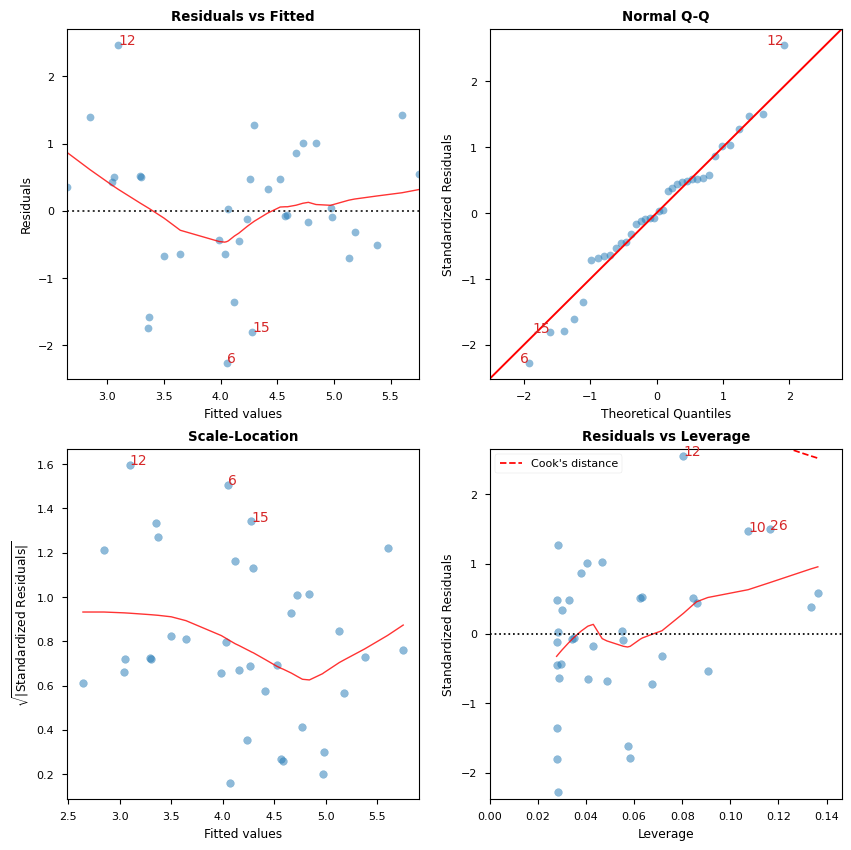

  Features  VIF Factor
1    log_x        1.00
0    const       48.85


In [19]:
#| echo: false
cls1 = LinearRegDiagnostic(m1)
vif1, fig1, ax = cls1()
print(vif1)

#1. Horizontal red line is an indicator that the residual has a linear pattern
#2. Points spread along the diagonal line will suggest normality of residuals
#3. Used to check homoscedasticity of the residuals. Horizontal line will suggest so.
#4. Points falling outside Cook's distance curves are considered observation that can sway the fit aka are influential. Good to have none outside the curves.

Regression diagnostics were used to assess the log-log OLS specification. HC3 robust standard errors were used to provide inference that is less sensitive to heteroskedasticity, while Huber robust regression was estimated as a sensitivity check for influential observations. The estimated coefficient is highly consistent across OLS, HC3 and Huber specifications (approximately 0.58), suggesting that the positive relationship is not driven by a small number of influential observations.

A **1% increase in GIA is associated with approximately a 0.58% increase in staff numbers. GIA alone accounts for around 39% of the variation in log staff numbers** in the analysed sample. As the coefficient is below 1, the relationship is sub-proportional: staff numbers increase with facility size, but at a slower rate.

In [20]:
#| include: false
print(f"Current analytical sample: {len(data_ldn_exstg_regression_m1)}")

Current analytical sample: 36


In [21]:
#| include: false
#Plot regression line
x, y = final_x, final_y
cols = ["id","lpa_name","current_occupier"]
df = data_ldn_exstg_regression_m1
ht = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i,c in enumerate(cols)]) + "<extra></extra>"
xl = np.linspace(df[x].min(), df[x].max(), 200)

fig = go.Figure([go.Scatter(x=df[x], y=df[y], mode="markers", marker=dict(size=7,opacity=0.9),
                            name="Observations", customdata=df[cols].to_numpy(), hovertemplate=ht)])
for mdl, name, style in [(m1,"OLS",dict(color="black")),
                         (m1_robust_HuberT,"Robust (RLM)",dict(color="red"))]:
    a,b = mdl.params["const"], mdl.params[x]
    fig.add_trace(go.Scatter(x=xl, y=a+b*xl, mode="lines", line=dict(width=2,**style), name=name))

fig.update_layout(width=1100,height=600,template="plotly_white",
                  title=dict(text="<br><span style='font-size:24px; font-weight:bold; color:%s;'>Baseline regression models' fitted lines</span>"%notes_colour,
                             x=0.03,xanchor="left",y=0.98,yanchor="top"),
                  margin=dict(t=90),legend=dict(font=dict(color=labels_colour)))
fig.update_xaxes(title_text="Log Gross Internal Area, 1000sqm",title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Log Total staff",title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

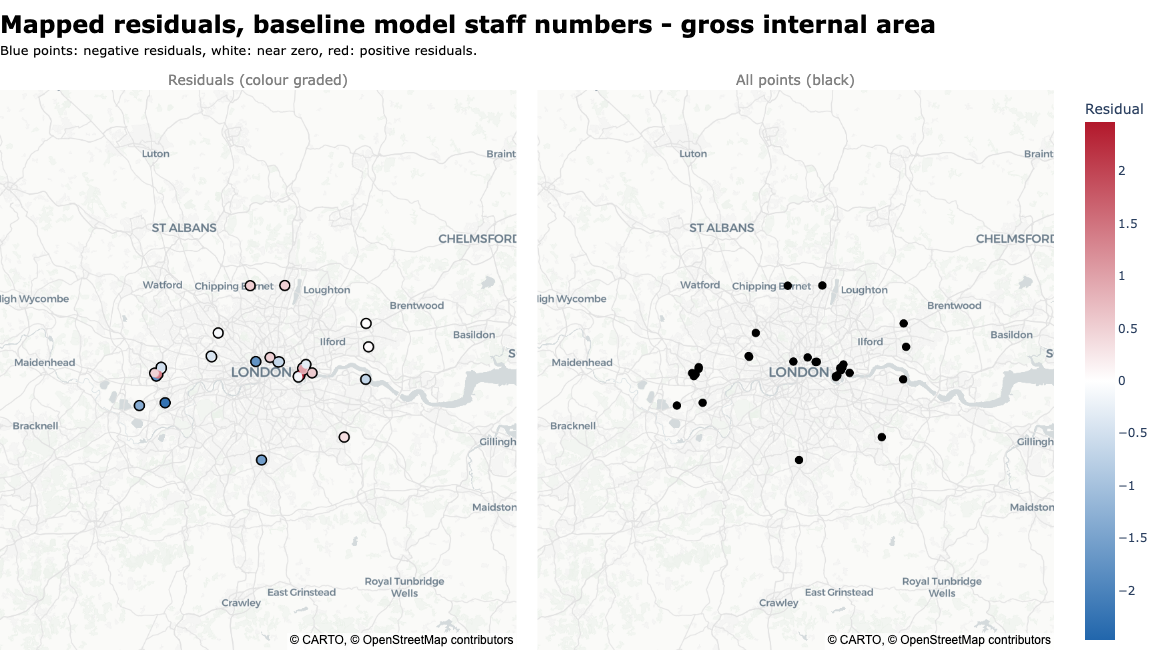

In [30]:
#| include: false
# map residuals for analysis
g = data_ldn_exstg_regression_m1.to_crs(4326).copy()
g["residual"] = m1.resid
g["lon"], g["lat"] = g.geometry.x, g.geometry.y

cols = ["id","current_occupier","lpa_name","b8_gia_1000_sqm","b8_total_staff_fte"]
ht = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols)]) + "<extra></extra>"

# blue -> white -> red
rwb_scale = [
    [0.0, "#2166ac"],
    [0.5, "#ffffff"],
    [1.0, "#b2182b"]
]

fig = make_subplots(cols=2, horizontal_spacing=0.02,
                    subplot_titles=("Residuals (colour graded)", "All points (black)"),
                    specs=[[{"type": "map"}, {"type": "map"}]])

# black outline layer
fig.add_trace(go.Scattermap(
    lat=g["lat"], lon=g["lon"], mode="markers",
    marker=dict(size=12, color="black", opacity=1),
    customdata=g[cols].to_numpy(),
    hovertemplate=ht,
    showlegend=False
), 1, 1)

# coloured residual layer
fig.add_trace(go.Scattermap(
    lat=g["lat"], lon=g["lon"], mode="markers",
    marker=dict(
        size=9,
        color=g["residual"],
        colorscale=rwb_scale,
        cmid=0,
        opacity=1,
        showscale=True,
        colorbar=dict(title="Residual")
    ),
    customdata=g[cols].to_numpy(),
    hovertemplate=ht,
    showlegend=False
), 1, 1)

fig.add_trace(go.Scattermap(
    lat=g["lat"], lon=g["lon"], mode="markers",
    marker=dict(size=9, color="black", opacity=1),
    customdata=g[cols].to_numpy(),
    hovertemplate=ht,
    showlegend=False
), 1, 2)

fig.update_layout(
    map=dict(style="carto-positron",
             center=dict(lat=51.50758519898516, lon=-0.1281236104918927),
             zoom=8),
    map2=dict(style="carto-positron",
              center=dict(lat=51.50758519898516, lon=-0.1281236104918927),
              zoom=8),
    height=650, width=1400,
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour};'>"
            "Mapped residuals, baseline model staff numbers - gross internal area</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
            "Blue points: negative residuals, white: near zero, red: positive residuals.</span>"
        ),
        x=0.00, xanchor="left",
        y=0.95, yanchor="top"
    ),
    legend=dict(font=dict(color=labels_colour)),
    margin=dict(l=0, r=0, t=90, b=0)
)

fig.update_annotations(font=dict(size=14, color=labels_colour))

fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "figure",
        "scale": 4
    }
})

Mapped residuals suggest some spatial patterning: positive residuals appear around visibly clustered locations such as Canary Wharf and Southall, while other areas show a mix of positive and negative residuals.

## Alternative explanatory variable

We also test IT load capacity as an alternative explanatory variable because, among the non-area measures, it showed one of the closest p-values to the 5% significance threshold in the initial screening. 

Compared with GIA, IT load shows a weaker and less stable relationship with staff numbers. Its coefficient is still positive (β=0.488), but the model explains less variation (R²=0.242 versus 0.394 for GIA) and the association is not statistically significant under OLS or HC3. The Huber model reaches significance, suggesting that the result may be sensitive to influential observations. We conclude that GIA provides stronger and more consistent evidence of an association with staff numbers, while the IT load result remains suggestive but uncertain, particularly given the much smaller sample (n=15 versus n=36).

In [23]:
# _________________________________________________________________
# Log-log regression:
# log(staff) ~ log(IT load)
# _________________________________________________________________

yvar_m3 = "b8_total_staff_fte"
xvar_m3 = "it_load_capacity_mw"

data_ldn_exstg_regression_m3 = (
    data_ldn_exstg
    .dropna(subset=[yvar_m3, xvar_m3])
    .copy()
)

# log requires positive values
data_ldn_exstg_regression_m3 = data_ldn_exstg_regression_m3[
    (data_ldn_exstg_regression_m3[yvar_m3] > 0) &
    (data_ldn_exstg_regression_m3[xvar_m3] > 0)
].copy()

data_ldn_exstg_regression_m3["log_staff_m3"] = np.log(
    data_ldn_exstg_regression_m3[yvar_m3]
)
data_ldn_exstg_regression_m3["log_itload_m3"] = np.log(
    data_ldn_exstg_regression_m3[xvar_m3]
)

y_m3 = data_ldn_exstg_regression_m3["log_staff_m3"]
X_m3 = sm.add_constant(data_ldn_exstg_regression_m3[["log_itload_m3"]])

m3 = sm.OLS(y_m3, X_m3).fit()
m3_robust_se = sm.OLS(y_m3, X_m3).fit(cov_type="HC3")
m3_robust_HuberT = sm.RLM(
    y_m3, X_m3, M=sm.robust.norms.HuberT()
).fit()

models_m3 = [m3, m3_robust_se, m3_robust_HuberT]

model_summary_m3 = pd.DataFrame({
    "Model": ["OLS", "OLS (HC3)", "Robust (HuberT)"],
    "N": [int(m.nobs) for m in models_m3],
    "Intercept": [m.params["const"] for m in models_m3],
    "IT load coef.": [m.params["log_itload_m3"] for m in models_m3],
    "IT load SE": [m.bse["log_itload_m3"] for m in models_m3],
    "IT load p": [m.pvalues["log_itload_m3"] for m in models_m3],
    "R²": [m3.rsquared, m3_robust_se.rsquared, np.nan]
}).round(3)

model_summary_m3

,Model,N,Intercept,IT load coef.,IT load SE,IT load p,R²
0,OLS,15,2.832,0.488,0.240,0.063,0.242
1,OLS (HC3),15,2.832,0.488,0.299,0.102,0.242
2,Robust (HuberT),15,2.957,0.457,0.227,0.044,NaN


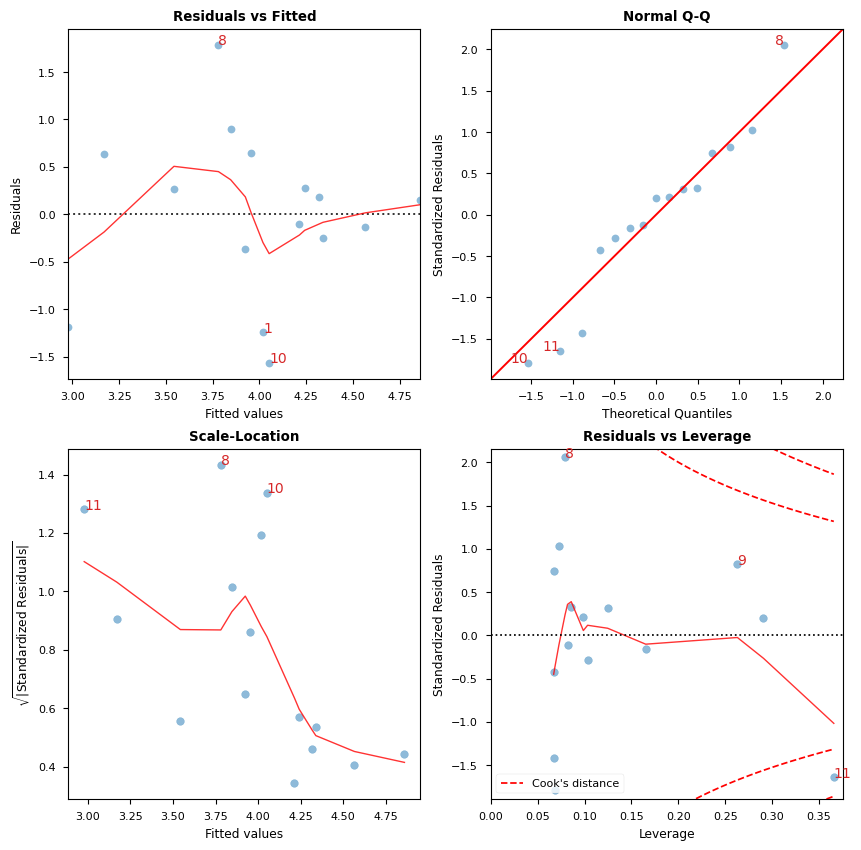

        Features  VIF Factor
1  log_itload_m3        1.00
0          const        6.89


In [24]:
#| echo: false
cls3 = LinearRegDiagnostic(m3)
vif3, fig3, ax = cls3()
print(vif3)

In [25]:
#| include: false
x, y = X_m3.columns[1], y_m3.name
df = data_ldn_exstg_regression_m3
cols = ["id", "lpa_name", "current_occupier"]
xl = np.linspace(df[x].min(), df[x].max(), 200)

fig = go.Figure(go.Scatter(
    x=df[x], y=df[y], mode="markers",
    marker=dict(size=7, opacity=0.9),
    name="Observations",
    customdata=df[cols].to_numpy(),
    hovertemplate="<br>".join([f"{c}: %{{customdata[{i}]}}" for i,c in enumerate(cols)]) + "<extra></extra>"
))

for mdl, name, color in [(m3, "OLS", "black"), (m3_robust_HuberT, "Robust (RLM)", "red")]:
    a, b = mdl.params["const"], mdl.params[x]
    fig.add_trace(go.Scatter(x=xl, y=a+b*xl, mode="lines",
                             line=dict(width=2, color=color), name=name))

fig.update_layout(
    width=1100, height=600, template="plotly_white",
    title=dict(
        text=f"<span style='font-size:24px; font-weight:bold; color:{notes_colour};'>IT load and staff numbers: fitted regression lines</span>",
        x=0.03
    ),
    legend=dict(font=dict(color=labels_colour))
)

fig.update_xaxes(title_text="Log IT load capacity (MW)", title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Log total staff (FTE)", title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))

fig.show(config={"toImageButtonOptions": {
    "format": "png", "filename": "m3_it_load_regression", "scale": 4
}})

## Further examination of predictors

Because missing data substantially reduces the sample size, only variables with relatively complete coverage can be retained for this step. We therefore test whether the relationship between GIA and staff numbers changes when site area and number of storeys are included in the same model.

In [26]:
# Multiple log-log regression:
# log(staff) ~ log(site area) + log(GIA) + log(storeys)

Xvars_m2 = ["application_details_site_area", "b8_gia_sqm", "b8_no_storeys"]
yvar_m2 = "b8_total_staff_fte"

data_ldn_exstg_regression_m2 = (
    data_ldn_exstg
    .dropna(subset=[yvar_m2] + Xvars_m2)
    .copy()
)

# log transformation requires positive values
data_ldn_exstg_regression_m2 = data_ldn_exstg_regression_m2[
    (data_ldn_exstg_regression_m2[[yvar_m2] + Xvars_m2] > 0).all(axis=1)
].copy()

data_ldn_exstg_regression_m2["log_staff_m2"] = np.log(data_ldn_exstg_regression_m2[yvar_m2])
data_ldn_exstg_regression_m2["log_site_area_m2"] = np.log(data_ldn_exstg_regression_m2["application_details_site_area"])
data_ldn_exstg_regression_m2["log_gia_m2"] = np.log(data_ldn_exstg_regression_m2["b8_gia_sqm"])
data_ldn_exstg_regression_m2["log_storeys_m2"] = np.log(data_ldn_exstg_regression_m2["b8_no_storeys"])

y_m2 = data_ldn_exstg_regression_m2["log_staff_m2"]
X_m2 = sm.add_constant(
    data_ldn_exstg_regression_m2[
        ["log_site_area_m2", "log_gia_m2", "log_storeys_m2"]
    ]
)

m2 = sm.OLS(y_m2, X_m2).fit()
m2_robust_se = sm.OLS(y_m2, X_m2).fit(cov_type="HC3")
m2_robust_HuberT = sm.RLM(
    y_m2, X_m2, M=sm.robust.norms.HuberT()
).fit()


In [27]:
#| echo: false
model_summary_m2 = pd.DataFrame({
    "Model": ["OLS", "OLS (HC3)", "Robust (HuberT)"],
    "N": [int(m.nobs) for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Intercept": [m.params["const"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Site area coef.": [m.params["log_site_area_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Site area SE": [m.bse["log_site_area_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Site area p": [m.pvalues["log_site_area_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "GIA coef.": [m.params["log_gia_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "GIA SE": [m.bse["log_gia_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "GIA p": [m.pvalues["log_gia_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Storeys coef.": [m.params["log_storeys_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Storeys SE": [m.bse["log_storeys_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "Storeys p": [m.pvalues["log_storeys_m2"] for m in [m2, m2_robust_se, m2_robust_HuberT]],
    "R²": [m2.rsquared, m2_robust_se.rsquared, np.nan]
}).round(3)

model_summary_m2

,Model,N,Intercept,Site area coef.,Site area SE,Site area p,GIA coef.,GIA SE,GIA p,Storeys coef.,Storeys SE,Storeys p,R²
0,OLS,34,1.141,0.327,0.148,0.035,0.134,0.188,0.481,1.192,0.296,0.000,0.631
1,OLS (HC3),34,1.141,0.327,0.194,0.093,0.134,0.256,0.599,1.192,0.402,0.003,0.631
2,Robust (HuberT),34,1.546,0.321,0.156,0.039,0.096,0.198,0.627,1.177,0.312,0.000,NaN


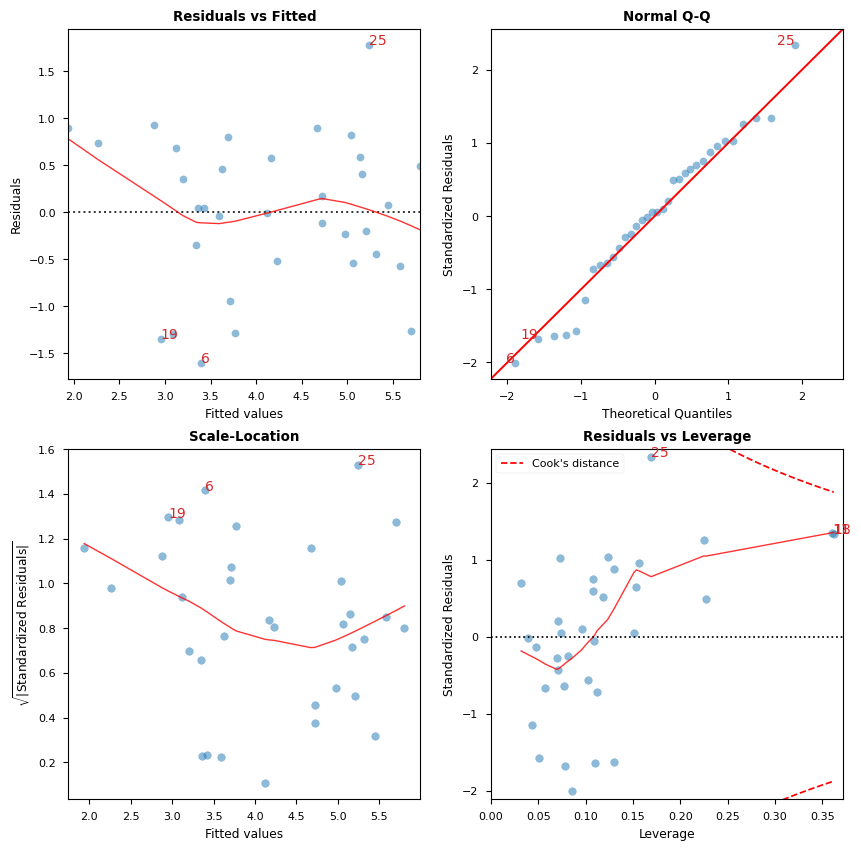

           Features  VIF Factor
3    log_storeys_m2        1.64
1  log_site_area_m2        2.39
2        log_gia_m2        3.02
0             const      120.75


In [28]:
#| echo: false
cls2 = LinearRegDiagnostic(m2)
vif2, fig2, ax = cls2()
print(vif2)

Compared with the GIA-only model, adding site area and number of storeys increases R² substantially, from about 0.39 to 0.63. GIA itself becomes small and non-significant, while number of storeys emerges as the strongest predictor; site area remains positive but is less robust under HC3.

Multicollinearity remains moderate rather than severe, with VIF values between 1.64 and 3.02, so the changing coefficients are unlikely to be explained by extreme overlap between predictors. Even so, around 37% of the variation in log staff numbers remains unexplained, indicating that factors beyond physical size and built form are likely to matter.

The Q–Q plot shows some departure from normality in the residual tails, although most observations follow the expected distribution reasonably closely.

In [33]:
# %pip install esda

/opt/conda/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 2 disconnected components.



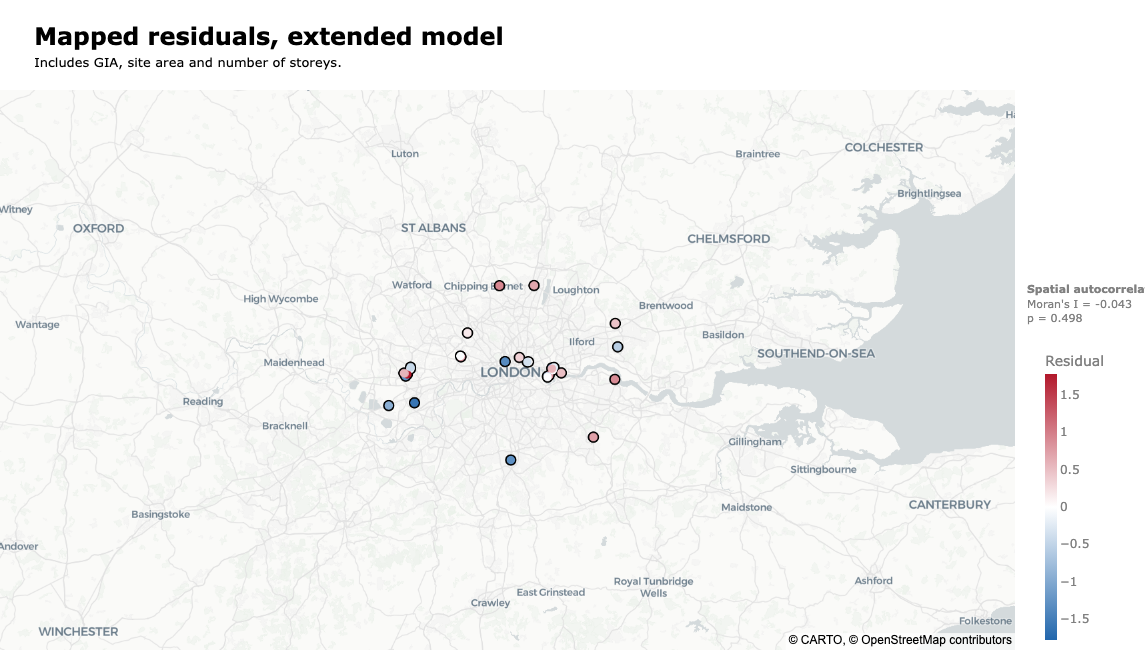

In [34]:
#| include: false

g = data_ldn_exstg_regression_m2.to_crs(4326).copy()
g["residual"] = m2.resid
g["lon"], g["lat"] = g.geometry.x, g.geometry.y

# Moran's I
gm = g.to_crs(27700)
w = KNN.from_dataframe(gm, k=4); w.transform = "R"
mi = Moran(gm["residual"].to_numpy(), w, permutations=999)

cols = ["id","current_occupier","lpa_name","b8_gia_1000_sqm","b8_total_staff_fte"]
ht = "<br>".join(f"{c}: %{{customdata[{i}]}}" for i,c in enumerate(cols)) + "<extra></extra>"
rwb = [[0,"#2166ac"],[.5,"#ffffff"],[1,"#b2182b"]]

fig = go.Figure()

# black outline
fig.add_trace(go.Scattermap(
    lat=g["lat"], lon=g["lon"], mode="markers",
    marker=dict(size=12,color="black"),
    customdata=g[cols], hovertemplate=ht, showlegend=False
))

# residuals
fig.add_trace(go.Scattermap(
    lat=g["lat"], lon=g["lon"], mode="markers",
    marker=dict(size=9,color=g["residual"],colorscale=rwb,cmid=0,
                showscale=True,
                colorbar=dict(title="Residual",len=.55,thickness=12,
                              x=1.02,y=0,yanchor="bottom")),
    customdata=g[cols], hovertemplate=ht, showlegend=False
))

fig.add_annotation(
    x=1.01,y=.62,xref="paper",yref="paper",
    text=f"<b>Spatial autocorrelation</b><br>Moran's I = {mi.I:.3f}<br>p = {mi.p_sim:.3f}",
    showarrow=False,align="left",xanchor="left",
    font=dict(size=11,color=labels_colour)
)

fig.update_layout(
    map=dict(style="carto-positron",
             center=dict(lat=51.5076,lon=-0.1281),zoom=8),
    width=900,height=650,
    title=dict(
        text=f"<span style='font-size:24px;font-weight:bold;color:{notes_colour};'>Mapped residuals, extended model</span><br>"
             f"<span style='font-size:13px;color:{notes_colour};'>Includes GIA, site area and number of storeys.</span>",
        x=.03,xanchor="left"
    ),
    margin=dict(l=0,r=130,t=90,b=0),
    font=dict(color=labels_colour)
)

fig.show(config={"toImageButtonOptions":{"format":"png","filename":"m2_residual_map","scale":4}})

The extended model residuals show no significant spatial autocorrelation (Moran’s I = −0.043, p = 0.498). Differences in data centre operating models are not captured in the dataset and therefore cannot be tested.

## Limitations

Results should be interpreted cautiously because of the small complete-case samples, missing technical data, and the observational nature of the dataset, which means the models identify associations rather than causal effects.